# Client API Usage

The following is a step-by-step guide that demonstrates how to use the Sen4CAP Python API in a Jupyter notebook.

The Python Sen4CAP client provides the following API methods: 

- `client.get_processes()`: listing existing processes,
- `client.get_process()`: get the details about a process,
- `client.execute_process()`: executing a given process execution request,
- `client.get_jobs()`: observing the jobs resulting from a process execution, 
- `client.get_job()`: getting a job's details,
- `client.get_job_result()`: getting a job's result, and finally
- `client.dismiss_job()`: cancelling a job.
- `client.open_job_result()`: open a result from a successful job.
- `client.show_app()`: open the client app UI.

and property

- `client.app_store`: to interact with the client app UI's process requests.


**Important:** Make sure you have already configured the client to run with the TAO Process API server. In a command shell run `sen4cap-client configure` and enter your credentials given that they differ from the provided default values. 

---

In [1]:
import json

from sen4cap_client.api import create_client

Get credentials allowing us to use the Sen4CAP processing system.

In [2]:
with open("credentials.json") as f:
    credentials = json.load(f)

Create a Sen4CAP client instance with your user credentials.

In [3]:
client = create_client(**credentials)

In [4]:
client.get_capabilities()

Capabilities(title='TAO OGC Process API service', description='REST API compliant with OGC Process API - Core for workflows invocation', links=[Link(href='/process/', rel='self', type='application/json', hreflang=None, title='This document', options=None), Link(href='/process/conformance', rel='http://www.opengis.net/def/rel/ogc/1.0/conformance', type='application/json', hreflang=None, title='OGC API - Processes conformance classes implemented by this service', options=None), Link(href='/process/processes', rel='http://www.opengis.net/def/rel/ogc/1.0/processes', type='application/json', hreflang=None, title='Metadata about the processes (workflows)', options=None), Link(href='/process/jobs', rel='http://www.opengis.net/def/rel/ogc/1.0/job-list', type='application/json', hreflang=None, title='Endpoint for job monitoring', options=None)])

In [5]:
client.get_conformance()

ConformanceDeclaration(conformsTo=['http://www.opengis.net/spec/ogcapi-processes-1/1.0/conf/core', 'http://www.opengis.net/spec/ogcapi-processes-1/1.0/conf/json'])

In [6]:
client.get_processes()

ProcessList(processes=[ProcessSummary(title='Sen4CAP Tillage Processor 5.0.0', description='Sen4CAP Tillage Detection Processor', keywords=None, metadata=None, additionalParameters=None, id='407', version='1.0', jobControlOptions=[<JobControlOptions.async_execute: 'async-execute'>], outputTransmission=[<TransmissionMode.value: 'value'>], links=None), ProcessSummary(title='L3B AOI Indicators Processor 5.0.4', description='Site Processing L3B NDVI Processor', keywords=['sen4cap', 'L3B', 'NDVI', 'LAI', 'FAPAR', 'FCOVER', 'NDWI'], metadata=None, additionalParameters=None, id='218', version='1.0', jobControlOptions=[<JobControlOptions.async_execute: 'async-execute'>], outputTransmission=[<TransmissionMode.value: 'value'>], links=None), ProcessSummary(title='Sen4CAP Crop Type', description='Sen4CAP Crop Type Processor', keywords=None, metadata=None, additionalParameters=None, id='208', version='1.0', jobControlOptions=[<JobControlOptions.async_execute: 'async-execute'>], outputTransmission=[

In [7]:
client.get_process(process_id="218")

ProcessDescription(title='L3B AOI Indicators Processor 5.0.4', description='Site Processing L3B NDVI Processor', keywords=None, metadata=None, additionalParameters=None, id='218', version='1.0', jobControlOptions=None, outputTransmission=None, links=None, inputs={'c30145a7-029c-4499-98bc-9903ca46531c': InputDescription(title='Start date', description='Start date', keywords=None, metadata=None, additionalParameters=None, minOccurs=1, maxOccurs=None, schema_=Schema(type=<DataType.string: 'string'>, title='Parameter Schema', description='Start date', enum=None, default='', nullable=False, readOnly=False, writeOnly=False, example=None, examples=None, deprecated=False, minimum=None, maximum=None, exclusiveMinimum=False, exclusiveMaximum=False, multipleOf=None, minLength=1, maxLength=255, format='date', pattern=None, contentMediaType=None, contentEncoding=None, contentSchema=None, items=None, minItems=0, maxItems=None, uniqueItems=False, properties=None, required=None, minProperties=0, maxPr

In [8]:
request = {
    'inputs': {
        'c30145a7-029c-4499-98bc-9903ca46531c': '2024-06-01',
        '472efeab-514a-4e15-9dba-d5812d653065': '2024-06-07',
        '691adc8e-9bba-4f42-86e2-ccd72189edc3': 'NDVI',
        'bed1920e-51c0-406e-b22e-70d1f86d95d4': 'POLYGON ((9.66 53.75,10.38 53.75,10.38 53.35,9.66 53.35,9.66 53.75))'
    },
    'outputs': {
        'db96d3e8-0243-48dc-ac9a-6470d2c39eb8': {
            "format": { "mediaType": "application/json" },
            "transmissionMode": "reference"
        }
    }
}

In [9]:
client.execute_process(process_id="218", request=request)

{'processID': 'L3B AOI Indicators Processor 5.0.4_virtual_2026-03-05T10:52:13',
 'type': 'process',
 'jobID': '647',
 'status': 'accepted',
 'created': '2026-06-29T14:45:06Z',
 'started': '2026-06-29T14:45:06Z',
 'updated': '2026-06-29T14:45:06Z',
 'progress': 0,
 'links': [{'href': 'http://localhost:8080/process/jobs/647',
   'rel': 'self',
   'type': 'application/json',
   'title': 'Job status'},
  {'href': 'http://localhost:8080/process/jobs/647/results',
   'rel': 'self',
   'type': 'application/json',
   'title': 'Job results (when status=successful)'}]}

In [8]:
job_list = client.get_jobs()
job_list

JobList(jobs=[JobInfo(jobID='647', processID='L3B AOI Indicators Processor 5.0.4', type='process', status=<JobStatus.successful: 'successful'>, message=None, created=datetime.datetime(2026, 6, 29, 14, 45, 6, tzinfo=TzInfo(0)), started=datetime.datetime(2026, 6, 29, 14, 45, 6, tzinfo=TzInfo(0)), finished=None, updated=datetime.datetime(2026, 6, 29, 14, 46, 7, tzinfo=TzInfo(0)), progress=100, links=[Link(href='/process/jobs647', rel='self', type='application/json', hreflang=None, title='Job status', options=None), Link(href='/process/jobs647/results', rel='self', type='application/json', hreflang=None, title='Job results (when status=successful)', options=None)], traceback=None)], links=[])

In [10]:
client.get_job("647")

JobInfo(jobID='647', processID='L3B AOI Indicators Processor 5.0.4', type='process', status=<JobStatus.successful: 'successful'>, message=None, created=datetime.datetime(2026, 6, 29, 14, 45, 6, tzinfo=TzInfo(0)), started=datetime.datetime(2026, 6, 29, 14, 45, 6, tzinfo=TzInfo(0)), finished=None, updated=datetime.datetime(2026, 6, 29, 14, 46, 7, tzinfo=TzInfo(0)), progress=100, links=[Link(href='/process/jobs/647', rel='self', type='application/json', hreflang=None, title='Job status', options=None), Link(href='/process/jobs/647/results', rel='self', type='application/json', hreflang=None, title='Job results (when status=successful)', options=None)], traceback=None)

In [12]:
job_results = client.get_job_results(job_id="647")
job_results

JobResults(root={'db96d3e8-0243-48dc-ac9a-6470d2c39eb8': Link(href='http://sen4x.tao.c-s.ro:8082/collections/L3B_NDVI/items/S2AGRI_L3BNDVI_PRD_S23_20260629T093945_A20240607T102559_T32UNE', rel=None, type='application/json', hreflang=None, title=None, options=None)})

In [8]:
data_array = client.open_job_result(job_id="647", asset_name="SNDVI")
data_array

C:\Users\norma\AppData\Local\Temp\ipykernel_420\1436610364.py:1: UserWarning: An error occurred while getting process description for process ID 'L3B AOI Indicators Processor 5.0.4'
  data_array = client.open_job_result(job_id="647", asset_name="SNDVI")


<xarray.DataArray (band: 1, y: 4520, x: 4834)> Size: 44MB
[21849680 values with dtype=int16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 36kB 5.957e+06 5.957e+06 ... 5.911e+06 5.911e+06
  * x            (x) float64 39kB 5.435e+05 5.435e+05 ... 5.918e+05 5.919e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -10000
    scale_factor:   1.0
    add_offset:     0.0

Matplotlib is building the font cache; this may take a moment.


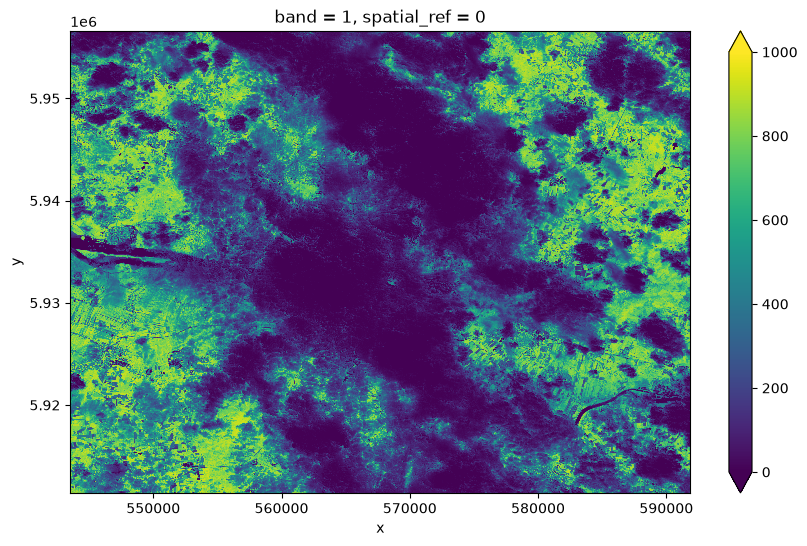

In [22]:
da.isel(band=0).plot.imshow(figsize=(10, 6), vmin=0, vmax=1000)